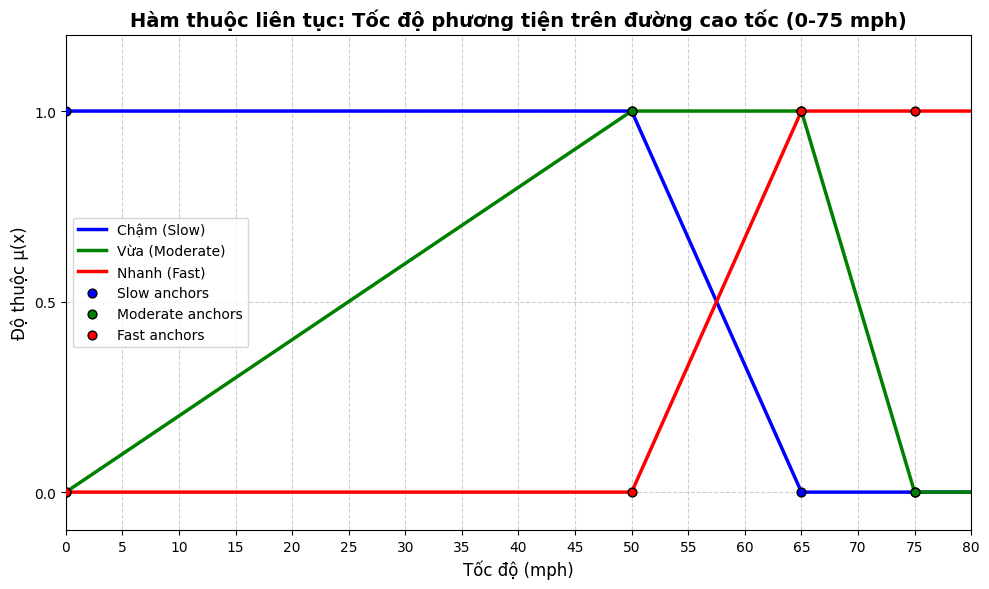

Tốc độ | μ_Chậm  μ_Vừa  μ_Nhanh
--------------------------------
     0 |   1.00    0.00      0.00
    50 |   1.00    1.00      0.00
    65 |   0.00    1.00      1.00
    75 |   0.00    0.00      1.00


In [9]:
import numpy as np
import matplotlib.pyplot as plt

anchors_slow = [(0, 1.0), (50, 1.0), (65, 0.0), (75, 0.0)]
anchors_moderate = [(0, 0.0), (50, 1.0), (65, 1.0), (75, 0.0)]
anchors_fast = [(0, 0.0), (50, 0.0), (65, 1.0), (75, 1.0)]


def fuzzy_interp(xs, anchors):
    """Nội suy tuyến tính từng khúc qua các điểm neo (x, mu)."""
    anchors = sorted(anchors)  # đảm bảo x tăng dần
    xa, ya = zip(*anchors)
    # Ngoại suy: giữ giá trị biên ở hai đầu
    mu = np.interp(xs, xa, ya, left=ya[0], right=ya[-1])
    return mu


# Trục x: tốc độ từ 0 đến 80 mph (để thấy rõ toàn bộ)
x = np.linspace(0, 80, 500)

mu_slow = fuzzy_interp(x, anchors_slow)
mu_moderate = fuzzy_interp(x, anchors_moderate)
mu_fast = fuzzy_interp(x, anchors_fast)

# ====== Vẽ đồ thị ======
plt.figure(figsize=(10, 6))

plt.plot(x, mu_slow, label="Chậm (Slow)", linewidth=2.5, color="blue")
plt.plot(x, mu_moderate, label="Vừa (Moderate)", linewidth=2.5, color="green")
plt.plot(x, mu_fast, label="Nhanh (Fast)", linewidth=2.5, color="red")

# Vẽ các điểm neo để minh họa
for anchors, label, color in [
    (anchors_slow, "Slow", "blue"),
    (anchors_moderate, "Moderate", "green"),
    (anchors_fast, "Fast", "red"),
]:
    xa, ya = zip(*anchors)
    plt.scatter(
        xa, ya, s=40, c=color, edgecolors="black", zorder=5, label=f"{label} anchors"
    )

plt.title(
    "Hàm thuộc liên tục: Tốc độ phương tiện trên đường cao tốc (0-75 mph)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Tốc độ (mph)", fontsize=12)
plt.ylabel("Độ thuộc μ(x)", fontsize=12)
plt.xticks(np.arange(0, 81, 5))
plt.yticks([0, 0.5, 1])
plt.ylim(-0.1, 1.2)
plt.xlim(0, 80)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig("anh1.png", dpi=300)
plt.show()

# ====== In bảng giá trị tại các điểm quan trọng ======
samples = [0, 50, 65, 75]
mu_slow_s = fuzzy_interp(np.array(samples), anchors_slow)
mu_mod_s = fuzzy_interp(np.array(samples), anchors_moderate)
mu_fast_s = fuzzy_interp(np.array(samples), anchors_fast)

print("Tốc độ | μ_Chậm  μ_Vừa  μ_Nhanh")
print("--------------------------------")
for xi, s, m, f in zip(samples, mu_slow_s, mu_mod_s, mu_fast_s):
    print(f"{xi:>6} | {s:>6.2f}  {m:>6.2f}  {f:>8.2f}")

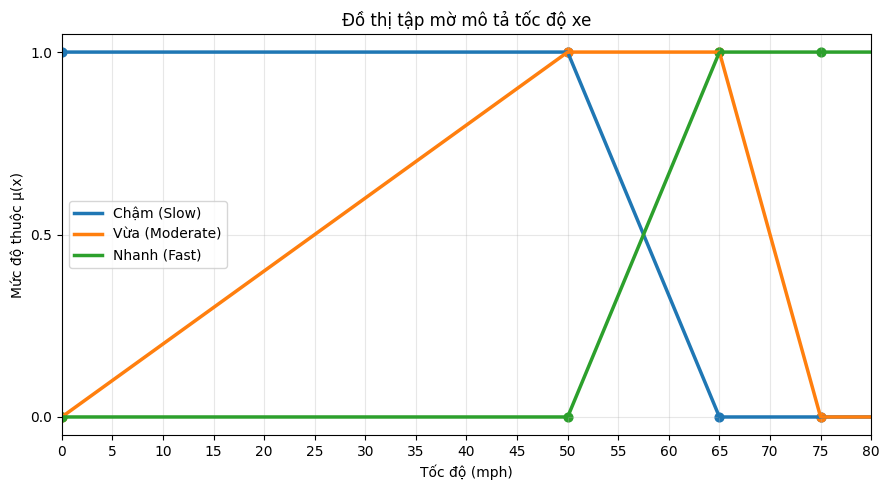

Tốc độ | μ_Chậm  μ_Vừa  μ_Nhanh
--------------------------------
     0 |   1.00    0.00      0.00
    50 |   1.00    1.00      0.00
    57 |   0.53    1.00      0.47
    65 |   0.00    1.00      1.00
    75 |   0.00    0.00      1.00
    80 |   0.00    0.00      1.00


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ====== Các điểm mốc (x, μ) cho từng tập mờ ======
# μ_A = {1/0, 1/50, 0/65, 0/75}
anchors_A = [(0, 1.0), (50, 1.0), (65, 0.0), (75, 0.0)]

# μ_B = {0/0, 0/50, 1/65, 1/75}
anchors_B = [(0, 0.0), (50, 0.0), (65, 1.0), (75, 1.0)]

# μ_C = {0/0, 1/50, 1/65, 0/75}
anchors_C = [(0, 0.0), (50, 1.0), (65, 1.0), (75, 0.0)]


def fuzzy_interp(xs, anchors):
    """Nội suy tuyến tính qua các điểm neo."""
    anchors = sorted(anchors)
    xa, ya = zip(*anchors)

    mu = np.interp(xs, xa, ya, left=ya[0], right=ya[-1])
    return mu


# ====== Trục tốc độ ======
x = np.linspace(0, 80, 400)

mu_slow = fuzzy_interp(x, anchors_A)
mu_mod = fuzzy_interp(x, anchors_C)
mu_fast = fuzzy_interp(x, anchors_B)

# ====== Vẽ đồ thị ======
plt.figure(figsize=(9, 5))

plt.plot(x, mu_slow, linewidth=2.5, label="Chậm (Slow)")
plt.plot(x, mu_mod, linewidth=2.5, label="Vừa (Moderate)")
plt.plot(x, mu_fast, linewidth=2.5, label="Nhanh (Fast)")

# ====== Vẽ điểm mốc ======
for anchors in [anchors_A, anchors_C, anchors_B]:
    xa, ya = zip(*anchors)
    plt.scatter(xa, ya, s=40)

# ====== Trang trí ======
plt.title("Đồ thị tập mờ mô tả tốc độ xe")
plt.xlabel("Tốc độ (mph)")
plt.ylabel("Mức độ thuộc μ(x)")

plt.xlim(0, 80)
plt.ylim(-0.05, 1.05)

plt.xticks(np.arange(0, 81, 5))
plt.yticks([0, 0.5, 1])

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# ====== In bảng giá trị ======
samples = [0, 50, 57, 65, 75, 80]

mu_s = fuzzy_interp(np.array(samples), anchors_A)
mu_m = fuzzy_interp(np.array(samples), anchors_C)
mu_f = fuzzy_interp(np.array(samples), anchors_B)

print("Tốc độ | μ_Chậm  μ_Vừa  μ_Nhanh")
print("--------------------------------")

for xi, s, m, f in zip(samples, mu_s, mu_m, mu_f):
    print(f"{xi:>6} | {s:>6.2f}  {m:>6.2f}  {f:>8.2f}")

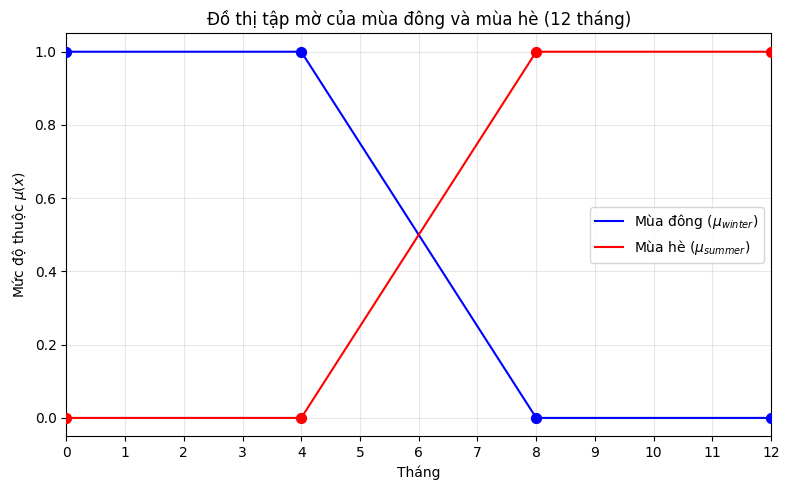

Tháng | μ_đông | μ_hè
---------------------
  1   |  1.00  |  0.00
  2   |  1.00  |  0.00
  3   |  1.00  |  0.00
  4   |  1.00  |  0.00
  5   |  0.75  |  0.25
  6   |  0.50  |  0.50
  7   |  0.25  |  0.75
  8   |  0.00  |  1.00
  9   |  0.00  |  1.00
  10   |  0.00  |  1.00
  11   |  0.00  |  1.00
  12   |  0.00  |  1.00


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ====== Điểm gãy (breakpoints) cho hàm thuộc liên tục ======
# Chỉ cần khai báo các điểm thay đổi độ dốc, np.interp sẽ tự nội suy tuyến tính
anchors_winter = [
    (0, 1.0),   # Bắt đầu
    (4, 1.0),   # Kết thúc vùng thuộc hoàn toàn
    (8, 0.0),   # Kết thúc vùng chuyển tiếp
    (12, 0.0)   # Giữ nguyên đến cuối năm
] 

anchors_summer = [
    (0, 0.0),
    (4, 0.0),
    (8, 1.0),
    (12, 1.0)
]

def fuzzy_interp(xs, anchors):
    """Nội suy tuyến tính từng khúc qua các điểm neo."""
    anchors = sorted(anchors)
    xa, ya = zip(*anchors)
    return np.interp(xs, xa, ya, left=ya[0], right=ya[-1])

# Trục x: mô phỏng liên tục từ 0 đến 12
x = np.linspace(0, 12, 500)
mu_winter = fuzzy_interp(x, anchors_winter)
mu_summer = fuzzy_interp(x, anchors_summer)

# ====== Vẽ đồ thị ======
plt.figure(figsize=(8, 5))
plt.plot(x, mu_winter, label="Mùa đông ($\\mu_{winter}$)", color="blue")
plt.plot(x, mu_summer, label="Mùa hè ($\\mu_{summer}$)", color="red")

# Đánh dấu các điểm gãy để dễ đối chiếu với đề
for ax, color, label in [(anchors_winter, "blue", "W"), (anchors_summer, "red", "S")]:
    xa, ya = zip(*ax)
    plt.scatter(xa, ya, s=50, color=color, zorder=5)

plt.title("Đồ thị tập mờ của mùa đông và mùa hè (12 tháng)")
plt.xlabel("Tháng")
plt.ylabel("Mức độ thuộc $\\mu(x)$")
plt.ylim(-0.05, 1.05)
plt.xlim(0, 12)
plt.xticks(np.arange(0, 13, 1))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("anh2.png")
plt.show()

# ====== Kiểm tra giá trị tại các tháng nguyên ======
samples = np.arange(1, 13)
mu_w_s = fuzzy_interp(samples, anchors_winter)
mu_s_s = fuzzy_interp(samples, anchors_summer)

print("Tháng | μ_đông | μ_hè")
print("---------------------")
for xi, w, s in zip(samples, mu_w_s, mu_s_s):
    print(f"  {xi}   |  {w:.2f}  |  {s:.2f}")

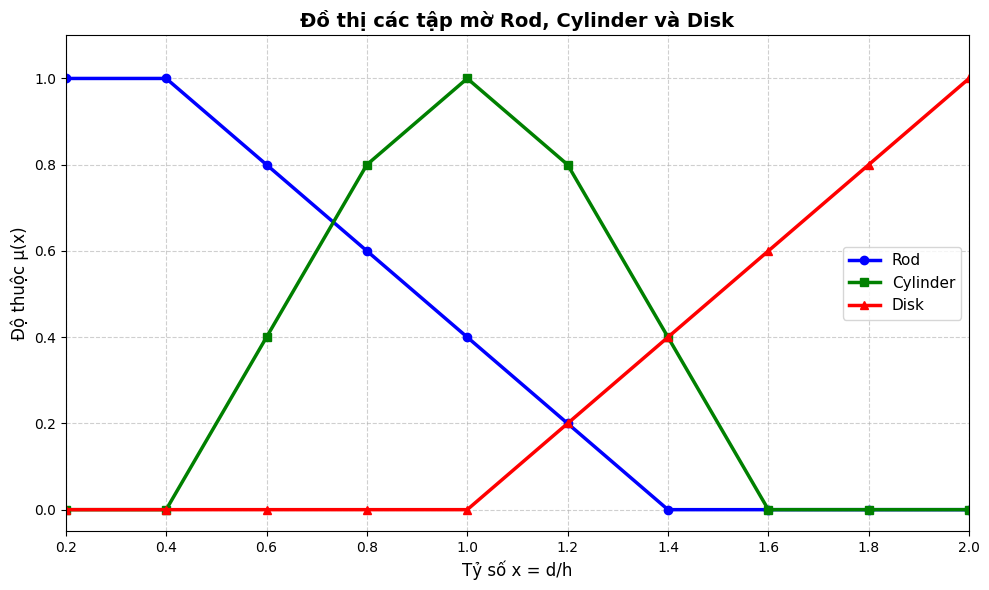

   x   | μ_Rod  μ_Cylinder  μ_Disk
------------------------------------
  0.2 |   1.0        0.0         0.0
  0.4 |   1.0        0.0         0.0
  0.6 |   0.8        0.4         0.0
  0.8 |   0.6        0.8         0.0
  1.0 |   0.4        1.0         0.0
  1.2 |   0.2        0.8         0.2
  1.4 |   0.0        0.4         0.4
  1.6 |   0.0        0.0         0.6
  1.8 |   0.0        0.0         0.8
  2.0 |   0.0        0.0         1.0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ====== Không gian nền X ======
X = np.array([0.2, 0.4, 0.6, 0.8, 1.0,
              1.2, 1.4, 1.6, 1.8, 2.0])

# ====== Các tập mờ ======

# Rod
mu_Rod = np.array([1.0, 1.0, 0.8, 0.6, 0.4,
                   0.2, 0.0, 0.0, 0.0, 0.0])

# Cylinder
mu_Cylinder = np.array([0.0, 0.0, 0.4, 0.8, 1.0,
                        0.8, 0.4, 0.0, 0.0, 0.0])

# Disk
mu_Disk = np.array([0.0, 0.0, 0.0, 0.0, 0.0,
                    0.2, 0.4, 0.6, 0.8, 1.0])

# ====== Vẽ đồ thị ======
plt.figure(figsize=(10, 6))

# Vẽ từng tập mờ
plt.plot(X, mu_Rod,
         marker='o',
         linewidth=2.5,
         color='blue',
         label='Rod')

plt.plot(X, mu_Cylinder,
         marker='s',
         linewidth=2.5,
         color='green',
         label='Cylinder')

plt.plot(X, mu_Disk,
         marker='^',
         linewidth=2.5,
         color='red',
         label='Disk')

# ====== Trang trí đồ thị ======
plt.title(
    "Đồ thị các tập mờ Rod, Cylinder và Disk",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Tỷ số x = d/h", fontsize=12)
plt.ylabel("Độ thuộc μ(x)", fontsize=12)

plt.xticks(X)
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

plt.xlim(0.2, 2.0)
plt.ylim(-0.05, 1.1)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

plt.tight_layout()

# Lưu ảnh
plt.savefig("anh3.png", dpi=300)

# Hiển thị
plt.show()

# ====== In bảng giá trị ======
print("   x   | μ_Rod  μ_Cylinder  μ_Disk")
print("------------------------------------")

for x, r, c, d in zip(X, mu_Rod, mu_Cylinder, mu_Disk):
    print(f"{x:>5.1f} | {r:>5.1f}      {c:>5.1f}       {d:>5.1f}")